In [25]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt
import alphashape
from itertools import combinations
from collections import defaultdict, deque
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ProcessPoolExecutor, as_completed


from shapely import points, contains
import random

In [26]:
#%pip install -e ..

In [27]:
from proj2dhullsampler import HistoryMatching
from proj2dhullsampler import plot_histograms_grid_5

In [44]:
working_dir = '/glade/work/qingyuany/camml_re'
case_name = "v4_extreme"

para = pd.read_csv("/glade/work/qingyuany/camml_re/v3_extreme/post_simulations/post_paras.csv", index_col=0)
para.shape



(99, 34)

In [46]:
test_case = HistoryMatching(working_dir, case_name, para, threshold_level=2.5)
test_case.drop_by_name(["LWCF"])
test_case.drop_by_n_survive(n_survive = 10000)
test_case.update_meta()



In [47]:
test_case.group_para_climatology(overlapping_threshold = 10000)
summary2d = test_case.shuffle_vars()

cldfrc_dp1                               and microp_aero_wsubi_scale                 :        0
clubb_c1                                 and microp_aero_npccn_scale                 :        0
microp_aero_wsubi_min                    and microp_aero_wsubi_scale                 :    10064
microp_aero_wsubi_scale                  and microp_aero_npccn_scale                 :   160935
clubb_c1                                 and microp_aero_wsubi_scale                 :   147183
zmconv_capelmt                           and microp_aero_wsubi_scale                 :    12195
zmconv_capelmt                           and microp_aero_npccn_scale                 :   555467
seasalt_emis_scale                       and microp_aero_npccn_scale                 :   538573
micro_mg_max_nicons                      and clubb_wpxp_L_thresh                     :   961431
cldfrc_dp2                               and microp_aero_wsubi_scale                 :   823042
sol_factic_interstitial                 

In [48]:
list(summary2d.values())[1]

,var1,var2,count
3,FSNTOA_zonal_45to55,SWCF_zonal_-55to-45,0
5,FSNTOA_zonal_45to55,SWCF_zonal_-45to-35,41636
1,FSNTOA_zonal_45to55,SWCF_zonal_-35to-25,63300
6,FSNTOA_zonal_45to55,FSNTOA_zonal_-45to-35,71151
30,SWCF_zonal_-55to-45,FSNTOA_zonal_35to45,99112
7,FSNTOA_zonal_45to55,FSNTOA_zonal_-35to-25,149560
8,FSNTOA_zonal_45to55,SWCF_zonal_55to65,172222
2,FSNTOA_zonal_45to55,SWCF_zonal_35to45,198952
4,FSNTOA_zonal_45to55,FSNTOA_zonal_35to45,198952
0,FSNTOA_zonal_45to55,SWCF_zonal_45to55,198952


In [49]:
no_overlap_2d_vars = ['PRECT_zonal_35to45', 'PRECT_zonal_-65to-55', 'SWCF_zonal_-55to-45', 'PRECT_zonal_-45to-35']

In [50]:
test_case.drop_no_overlap2d_vars(no_overlap_2d_vars)
test_case.group_para_climatology()
summary2d = test_case.shuffle_vars()
summary2d

cldfrc_dp1                               and microp_aero_wsubi_scale                 :    46318
clubb_c1                                 and microp_aero_npccn_scale                 :    41636
microp_aero_wsubi_min                    and microp_aero_wsubi_scale                 :    10064
microp_aero_wsubi_scale                  and microp_aero_npccn_scale                 :   160935
clubb_c1                                 and microp_aero_wsubi_scale                 :   147183
zmconv_capelmt                           and microp_aero_wsubi_scale                 :    12195
zmconv_capelmt                           and microp_aero_npccn_scale                 :   555467
seasalt_emis_scale                       and microp_aero_npccn_scale                 :   538573
micro_mg_max_nicons                      and clubb_wpxp_L_thresh                     :   961431
cldfrc_dp2                               and microp_aero_wsubi_scale                 :   823042
sol_factic_interstitial                 

{}

In [51]:
test_case.paras_vars

{('cldfrc_dp1', 'microp_aero_wsubi_scale'): ['FLUT_zonal_25to35',
  'TMQ_zonal_35to45',
  'TMQ_zonal_-5to5',
  'TMQ_zonal_45to55',
  'ave_LWCF',
  'FLUT_zonal_-15to-5',
  'FLUT_zonal_-5to5',
  'TMQ_zonal_-15to-5',
  'FLUT_zonal_-45to-35',
  'FLUT_zonal_5to15',
  'TMQ_zonal_5to15',
  'TMQ_zonal_25to35',
  'TMQ_zonal_15to25',
  'ave_FLUT',
  'PRECT_zonal_25to35',
  'FLUT_zonal_15to25',
  'FLUT_zonal_-35to-25'],
 ('clubb_c1', 'microp_aero_npccn_scale'): ['FSNTOA_zonal_45to55',
  'SWCF_zonal_45to55',
  'SWCF_zonal_-35to-25',
  'SWCF_zonal_35to45',
  'FSNTOA_zonal_35to45',
  'SWCF_zonal_-45to-35',
  'FSNTOA_zonal_-45to-35',
  'FSNTOA_zonal_-35to-25',
  'SWCF_zonal_55to65'],
 ('microp_aero_wsubi_min', 'microp_aero_wsubi_scale'): ['FLUT_zonal_45to55',
  'FLUT_zonal_55to65',
  'FLUT_zonal_-55to-45',
  'FLUT_zonal_-75to-65',
  'FLUT_zonal_65to75',
  'FLUT_zonal_-65to-55'],
 ('microp_aero_wsubi_scale',
  'microp_aero_npccn_scale'): ['FSNTOA_zonal_-25to-15', 'SWCF_zonal_-25to-15', 'SWCF_zonal_15t

In [52]:
test_case.drop_by_nvar_per_pair(n_var_thre=1)

In [53]:
test_case.paras_vars

{('cldfrc_dp1', 'microp_aero_wsubi_scale'): ['FLUT_zonal_25to35',
  'TMQ_zonal_35to45',
  'TMQ_zonal_-5to5',
  'TMQ_zonal_45to55',
  'ave_LWCF',
  'FLUT_zonal_-15to-5',
  'FLUT_zonal_-5to5',
  'TMQ_zonal_-15to-5',
  'FLUT_zonal_-45to-35',
  'FLUT_zonal_5to15',
  'TMQ_zonal_5to15',
  'TMQ_zonal_25to35',
  'TMQ_zonal_15to25',
  'ave_FLUT',
  'PRECT_zonal_25to35',
  'FLUT_zonal_15to25',
  'FLUT_zonal_-35to-25'],
 ('clubb_c1', 'microp_aero_npccn_scale'): ['FSNTOA_zonal_45to55',
  'SWCF_zonal_45to55',
  'SWCF_zonal_-35to-25',
  'SWCF_zonal_35to45',
  'FSNTOA_zonal_35to45',
  'SWCF_zonal_-45to-35',
  'FSNTOA_zonal_-45to-35',
  'FSNTOA_zonal_-35to-25',
  'SWCF_zonal_55to65'],
 ('microp_aero_wsubi_min', 'microp_aero_wsubi_scale'): ['FLUT_zonal_45to55',
  'FLUT_zonal_55to65',
  'FLUT_zonal_-55to-45',
  'FLUT_zonal_-75to-65',
  'FLUT_zonal_65to75',
  'FLUT_zonal_-65to-55'],
 ('microp_aero_wsubi_scale',
  'microp_aero_npccn_scale'): ['FSNTOA_zonal_-25to-15', 'SWCF_zonal_-25to-15', 'SWCF_zonal_15t

In [54]:
test_case.build_hulls()

In [55]:
test_case.orchestrate()

Running ('cldfrc_dp1', 'microp_aero_wsubi_scale'), the 0th simulation
There is overlap for ('cldfrc_dp1', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('clubb_c1', 'microp_aero_npccn_scale'), the 1th simulation
There is overlap for ('clubb_c1', 'microp_aero_npccn_scale'). Proceed to the next parameter pair
Running ('microp_aero_wsubi_min', 'microp_aero_wsubi_scale'), the 2th simulation
There is overlap for ('microp_aero_wsubi_min', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('microp_aero_wsubi_scale', 'microp_aero_npccn_scale'), the 3th simulation
Find nothing from 100000 pts
Find nothing, try to resolve it by breaking the variables into groups
First sample out_prev that needs greater sample size, which will take long
The size of out_prev is 111
	 	Running test to see if ('microp_aero_wsubi_scale', 'microp_aero_npccn_scale') could be break down and lead to non-overlapping
Try 5 combinations
Try one of the combinations
Try one of the

In [59]:
test_case.draw(n_pts=50000, n_threshold=5000, sample_threshold=10**9, max_workers=10, n_max=1000)

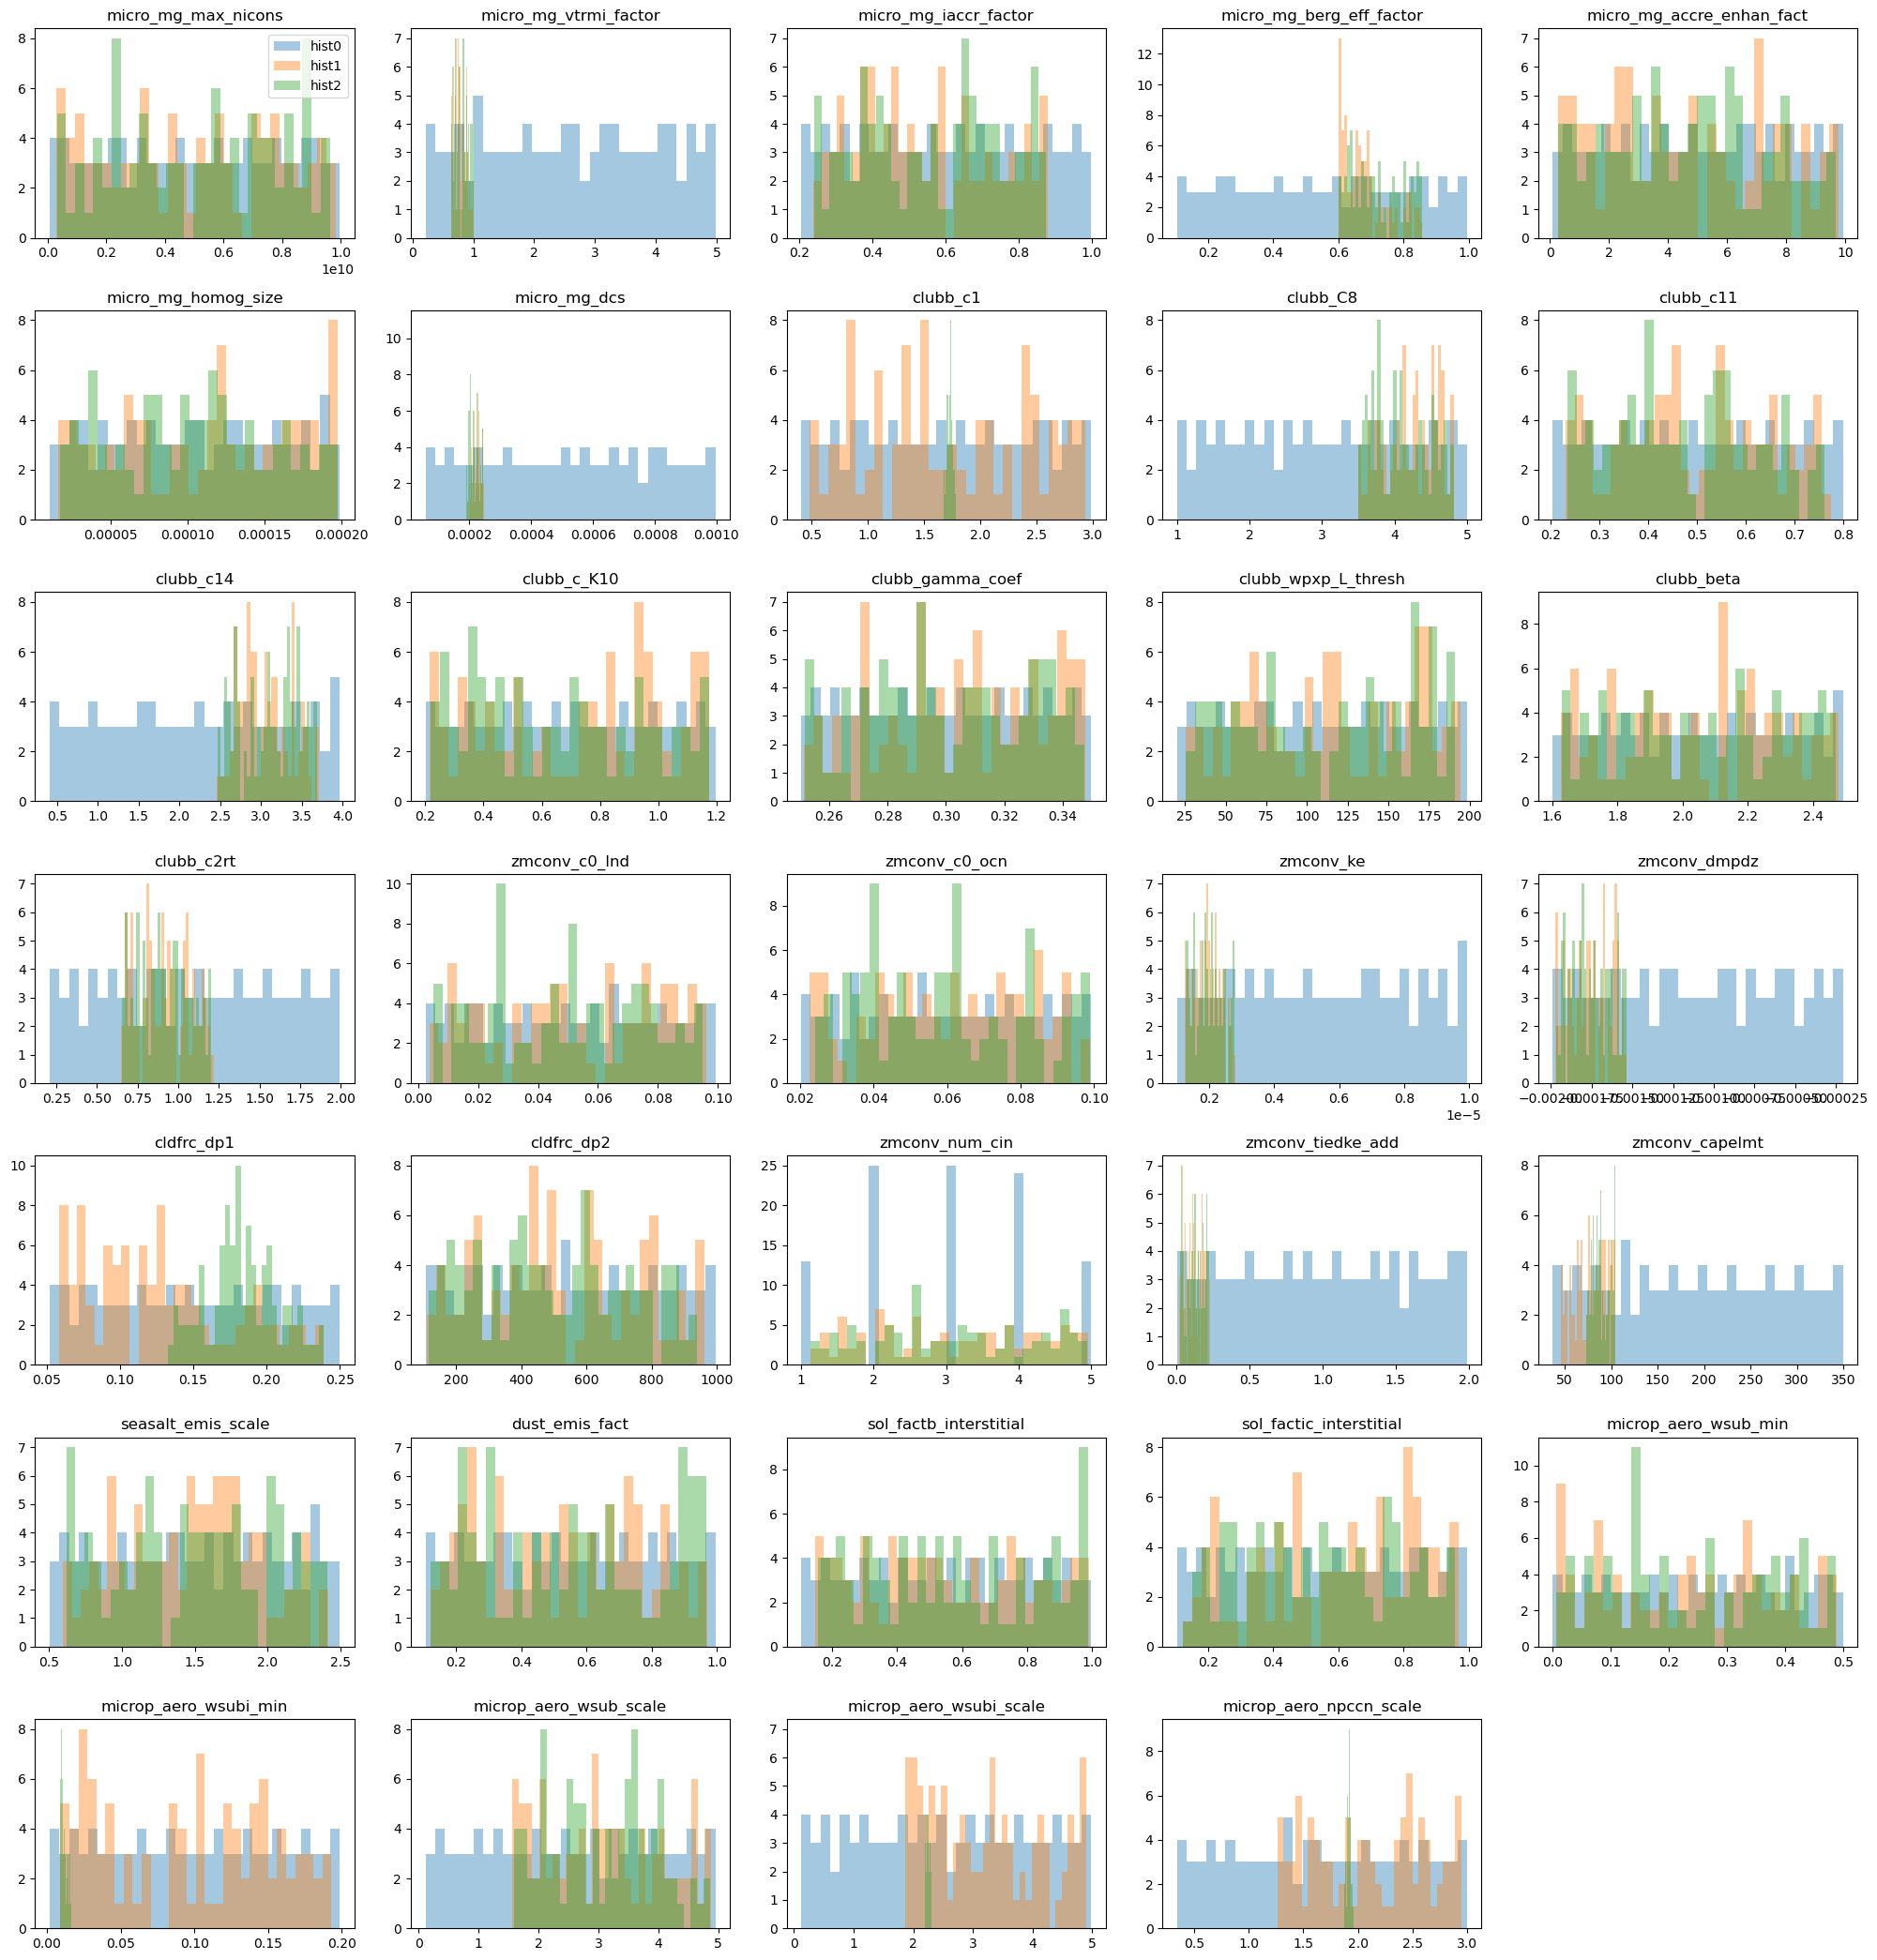

In [62]:
para0 = xr.open_dataset('/glade/work/qingyuany/camml_re/v0/parameter_34_100.nc').to_dataframe().drop(columns = ['Sample_nmb'])
para1 = pd.read_csv('/glade/work/qingyuany/camml_re/v1_filter_extreme/post_simulation/post_paras.csv', index_col=0)


plot_histograms_grid_5([para0, para, test_case.results.realscale_samples.iloc[:100, :]])

In [63]:
test_case.results.realscale_samples

,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,zmconv_capelmt,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale
0,1.557279e+09,0.971078,0.544433,0.695667,2.498178,0.000158,0.000245,1.742882,3.601347,0.752263,...,89.087088,2.108029,0.303911,0.162274,0.383781,0.060410,0.012854,1.802671,2.277669,1.920285
1,6.941538e+09,0.759978,0.560241,0.687951,8.662380,0.000186,0.000227,1.733140,3.793077,0.264075,...,74.873415,1.234669,0.889285,0.473487,0.905812,0.091852,0.009400,2.772196,2.252366,1.892766
2,8.499642e+09,0.927422,0.265220,0.789575,1.511111,0.000121,0.000234,1.727256,4.672327,0.760950,...,102.837123,1.769110,0.952861,0.777851,0.190707,0.118883,0.014185,4.089302,2.243404,1.920941
3,5.029524e+09,0.826605,0.495248,0.654196,4.502686,0.000123,0.000198,1.731237,4.528059,0.242855,...,80.414830,0.808936,0.540481,0.166769,0.840159,0.076160,0.009686,2.929939,2.277002,1.903881
4,2.666105e+09,0.927102,0.647258,0.710500,3.050845,0.000058,0.000243,1.758300,4.531390,0.520917,...,103.260268,1.793114,0.395694,0.420209,0.500767,0.420494,0.010037,3.270409,2.249785,1.901933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,4.245037e+09,0.761863,0.758071,0.683739,8.361472,0.000096,0.000229,1.711786,4.628738,0.478635,...,79.097716,2.117410,0.515928,0.808389,0.898367,0.392815,0.011923,4.778982,2.269718,1.944475
233,7.898064e+09,0.866008,0.388742,0.708877,5.764795,0.000185,0.000219,1.771626,3.854280,0.546458,...,94.453102,2.208816,0.236021,0.876773,0.610372,0.359344,0.009922,3.673095,2.241813,1.906648
234,3.623251e+09,0.804006,0.841928,0.760961,7.238778,0.000107,0.000203,1.704632,4.399701,0.289933,...,102.887122,1.737364,0.233700,0.255262,0.777574,0.318372,0.012802,2.698794,2.221434,1.897981
235,1.121942e+09,0.872319,0.487803,0.758226,8.649929,0.000152,0.000243,1.730773,4.044912,0.446745,...,90.012786,1.598191,0.772052,0.590137,0.670180,0.372434,0.011012,1.838160,2.259498,1.917455


In [64]:
test_case.save_samples(n = 100)
test_case.write_specifications()

(237, 34)
['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '062', '063', '064', '065', '066', '067', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '078', '079', '080', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '095', '096', '097', '098', '099', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '1

In [3]:
import xarray as xr
xr.open_dataset('/glade/work/qingyuany/camml_re/v4_extreme/sel_para_realscale.nc').to_dataframe().head()

,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale,Sample_nmb
nmb_sim,,,,,,,,,,,,,,,,,,,,,
0,1.557279e+09,0.971078,0.544433,0.695667,2.498178,0.000158,0.000245,1.742882,3.601347,0.752263,...,2.108029,0.303911,0.162274,0.383781,0.060410,0.012854,1.802671,2.277669,1.920285,001
1,6.941538e+09,0.759978,0.560241,0.687951,8.662380,0.000186,0.000227,1.733140,3.793077,0.264075,...,1.234669,0.889285,0.473487,0.905812,0.091852,0.009400,2.772196,2.252366,1.892766,002
2,8.499642e+09,0.927422,0.265220,0.789575,1.511111,0.000121,0.000234,1.727256,4.672327,0.760950,...,1.769110,0.952861,0.777851,0.190707,0.118883,0.014185,4.089302,2.243404,1.920941,003
3,5.029524e+09,0.826605,0.495248,0.654196,4.502686,0.000123,0.000198,1.731237,4.528059,0.242855,...,0.808936,0.540481,0.166769,0.840159,0.076160,0.009686,2.929939,2.277002,1.903881,004
4,2.666105e+09,0.927102,0.647258,0.710500,3.050845,0.000058,0.000243,1.758300,4.531390,0.520917,...,1.793114,0.395694,0.420209,0.500767,0.420494,0.010037,3.270409,2.249785,1.901933,005


In [4]:
xr.open_dataset('/glade/work/qingyuany/camml_re/v3_extreme/sel_para_realscale.nc').to_dataframe().head()

,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale,Sample_nmb
nmb_sim,,,,,,,,,,,,,,,,,,,,,
0,8.764451e+09,0.734829,0.504504,0.660242,0.583751,0.000041,0.000231,2.397564,4.297589,0.520757,...,0.642010,0.440628,0.224962,0.838330,0.102638,0.147649,4.601857,3.895177,2.947053,001
1,6.249091e+09,0.719602,0.451698,0.623707,4.913654,0.000178,0.000216,2.094584,3.640743,0.392219,...,1.147832,0.284604,0.790406,0.334195,0.078667,0.133590,3.908127,2.368320,2.932574,002
2,3.643257e+09,0.734745,0.631602,0.602616,3.506507,0.000058,0.000234,2.936606,4.589038,0.647695,...,1.691183,0.121225,0.210095,0.945064,0.183940,0.022292,2.124240,2.945122,1.680474,003
3,7.799491e+09,0.867221,0.449595,0.698135,3.682035,0.000031,0.000236,0.483083,3.766823,0.356188,...,1.891392,0.760065,0.800012,0.472317,0.240086,0.186566,2.662161,2.162034,1.920328,004
4,3.249013e+09,0.996169,0.395150,0.731877,7.910945,0.000163,0.000216,2.104301,4.542901,0.281722,...,1.820523,0.252576,0.662260,0.698986,0.479244,0.034171,2.748193,4.844915,1.837668,005


In [46]:
para0

,Sample_nmb,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,...,zmconv_capelmt,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale
nmb_sim,,,,,,,,,,,,,,,,,,,,,
0,001,7.215175e+08,1.267022,0.823488,0.407703,1.851045,0.000178,0.000057,0.979179,4.927267,...,120.142934,1.105597,0.277262,0.502497,0.570835,0.041296,0.149827,2.794938,2.535322,1.815058
1,002,9.251974e+09,2.202746,0.889678,0.972194,4.505631,0.000023,0.000122,2.843388,2.428296,...,247.383200,2.407157,0.130452,0.937825,0.529226,0.246292,0.121583,4.902108,3.479043,2.910264
2,003,8.068178e+09,2.323339,0.986899,0.235567,7.137165,0.000153,0.000932,1.953316,1.002911,...,193.238508,1.068723,0.699927,0.769825,0.822189,0.176582,0.072601,1.144683,4.779097,2.030965
3,004,3.647816e+09,3.435071,0.513808,0.591165,5.620052,0.000028,0.000420,2.211190,3.873757,...,244.702000,1.573608,0.492635,0.602469,0.207164,0.468828,0.045972,1.552842,1.753745,2.494477
4,005,4.757067e+09,4.596029,0.509063,0.145424,4.312668,0.000095,0.000769,2.008266,4.541826,...,137.376485,0.891367,0.742055,0.531384,0.460259,0.190384,0.004235,2.608563,2.328749,2.951035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,096,2.661275e+08,3.304371,0.836747,0.741553,2.671713,0.000104,0.000446,1.078126,1.094893,...,260.229482,1.952411,0.840636,0.545733,0.638349,0.223556,0.158511,2.836542,0.206552,2.616847
96,097,3.716642e+09,1.167166,0.395525,0.830053,1.321274,0.000195,0.000983,1.369105,2.029970,...,300.029807,2.494319,0.483260,0.508618,0.165473,0.021735,0.074680,0.821566,1.673414,0.615581
97,098,6.423990e+08,2.294843,0.797352,0.360380,5.195998,0.000068,0.000804,2.539905,2.228849,...,46.372127,1.928076,0.901520,0.745363,0.938327,0.321258,0.177249,4.458443,4.986438,0.486167
